# Execução do pipeline completo

Roda o pré-processamento (conversão de anotação + Mediana + CLAHE) sobre o dataset inteiro, gerando os splits treino/validação/teste (70%/15%/15%) usados no treino do modelo. 

<small>Rodar só depois de calibrar `clahe_clip` no notebook 02 e atualizar o default em `filters.py`.</small>

In [1]:
import sys
from pathlib import Path

REPO_ROOT = Path("../../..").resolve()
sys.path.insert(0, str(REPO_ROOT / "src" / "preprocessing"))

import pipeline

# Combina train.txt + test.txt num pool único e reparticiona em 70/15/15
# (treino/validação/teste), embaralhado com seed fixa.
counts = pipeline.run()
print(f"Pool total (train.txt + test.txt filtrados): {counts['pool']}")
print(f"Train: {counts['train']} ({counts['train'] / counts['pool']:.1%})")
print(f"Val:   {counts['val']} ({counts['val'] / counts['pool']:.1%})")
print(f"Test:  {counts['test']} ({counts['test'] / counts['pool']:.1%})")


Pool total (train.txt + test.txt filtrados): 3180
Train: 2226 (70.0%)
Val:   477 (15.0%)
Test:  477 (15.0%)


Confere que a contagem de imagens processadas bate com a de labels em cada split.

In [2]:
processed = pipeline.PROCESSED_ROOT
for split in ("train", "val", "test"):
    n_images = len(list((processed / "images" / split).glob("*.jpg")))
    n_labels = len(list((processed / "labels" / split).glob("*.txt")))
    print(f"{split}: {n_images} imagens, {n_labels} labels")


train: 2226 imagens, 2226 labels
val: 477 imagens, 477 labels
test: 477 imagens, 477 labels


Visualiza algumas amostras processadas (mediana + CLAHE aplicados), pra conferência visual rápida.

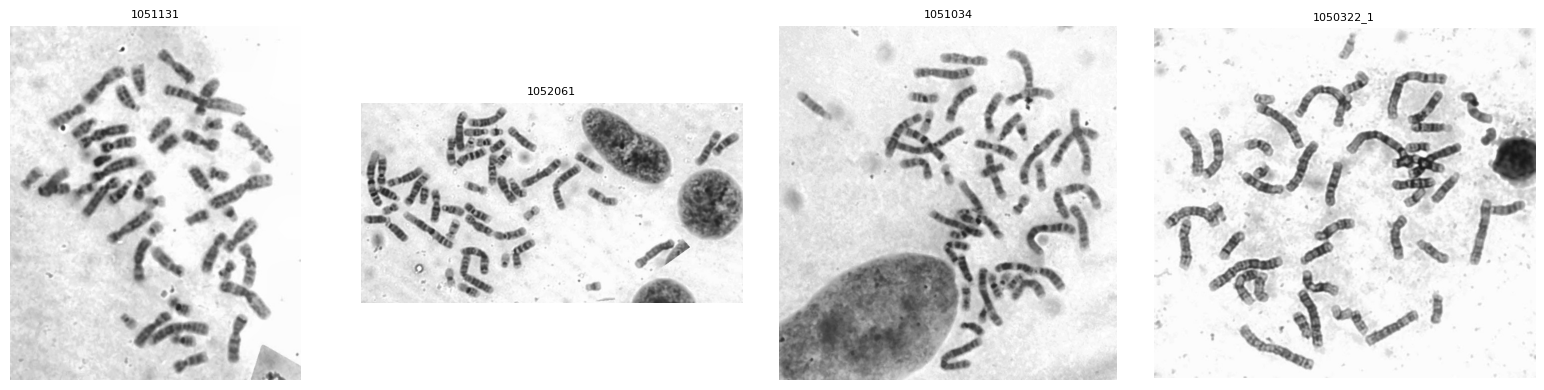

In [3]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

sample_images = list((processed / "images" / "train").glob("*.jpg"))[:4]
fig, axes = plt.subplots(1, len(sample_images), figsize=(4 * len(sample_images), 4))
for ax, img_path in zip(axes, sample_images):
    ax.imshow(mpimg.imread(img_path))
    ax.set_title(img_path.stem, fontsize=8)
    ax.axis("off")
plt.tight_layout()
plt.show()


Gera as partições de k-fold cross-validation sobre o pool de treino+validação

In [4]:
fold_counts = pipeline.generate_kfold_splits(k=5)
for c in fold_counts:
    print(f"fold {c['fold']}: {c['train']} train, {c['val']} val")


fold 0: 2162 train, 541 val
fold 1: 2162 train, 541 val
fold 2: 2162 train, 541 val
fold 3: 2163 train, 540 val
fold 4: 2163 train, 540 val
